<a href="https://colab.research.google.com/github/MelisaYasak/transformer_arch/blob/main/positional_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Positional Encoder
Transformers mimarisinde tokenlar aynı anda işlenir. Paralel işleme yapılır. Ama hangi tokenın hangi tokendan sonra geldiği bilgisi yoktur. Buna permutation invariance denir. Bunun çözümü için Encoder bloğunun inputuna tokenın pozisyon bilgisini göndermektir.



## Positional Encoder Uygulaması

Position sign aşağıdaki formül ile oluşturulur.

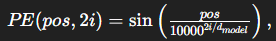

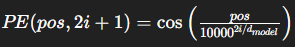

İki formülün bulunması çeşitliliği sağlayabilmek içindir. sin() ve cos() periyodik fonskiyonlardır. Bu fonksiyonlar her pozisyon için benzersiz desenler üretir. Formül seçimi bir önceki adımın çıktısı olan embedding vector'e göre belirlenir.
* Embedding vector'ün çift index'indeki değerler için 2i içeren sin() formülü
* Embedding vector'ün tek index'indeki değerler için 2i+1 içeren cos() formülü kullanılır.

sin() ve cos() fonksiyonlarının beraber kullanılmasının nedeni modelin vektör uzayındaki mesayeyi ve yönü anlayabilmesini sağlamaktır. Bunlar sayesinde model "A" token'ının "B" token'ından pozisyonel olarak ne kadar uzakta olduğunu hesaplar. Bu durumda geometriyi (wave) öğrenmiş olur.

In [1]:
import torch
import math

In [2]:
def positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)

    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = math.sin(pos / (10000 ** ((2 * i)/d_model)))

            if i + 1 < d_model:
                pe[pos, i+1] = math.cos(pos / (10000 ** ((2 * i)/d_model)))

    return pe

In [3]:
seq_len = 5
d_model = 8

pe = positional_encoding(seq_len, d_model)

print("Positional Encoding shape:", pe.shape)
print(pe)

Positional Encoding shape: torch.Size([5, 8])
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9998e-03,  9.9995e-01,  1.0000e-04,
          1.0000e+00,  1.0000e-06,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9999e-02,  9.9980e-01,  2.0000e-04,
          1.0000e+00,  2.0000e-06,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9996e-02,  9.9955e-01,  3.0000e-04,
          1.0000e+00,  3.0000e-06,  1.0000e+00],
        [-7.5680e-01, -6.5364e-01,  3.9989e-02,  9.9920e-01,  4.0000e-04,
          1.0000e+00,  4.0000e-06,  1.0000e+00]])


Input olarak
* seq_len = Cümledeki token sayısı
* d_model = Her token'ın kaç boyutlu vektörle temsil edildiği (Gerçek modellerde 512 veya 1024 olur)



Output olarak oluşan shape şunu açıklar: 5 pozisyon var ve 8 boyutlu

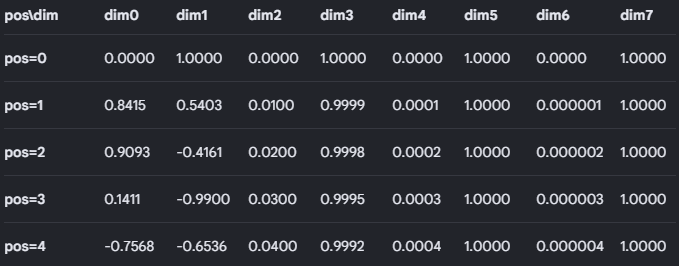



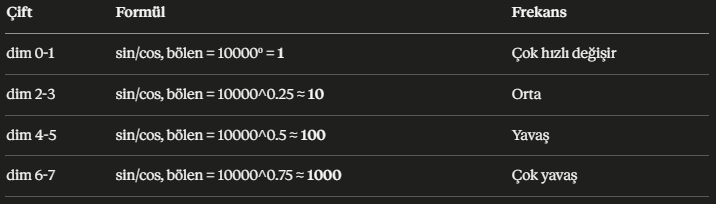

Sol dimler (0-1) hızlı değişir → pos değişince sin/cos büyük sıçrar

Sağ dimler (6-7) çok yavaş → pos=1,2,3,4 için neredeyse hep 1.0000 görünür

Model bu farkları birleştirerek her pozisyona benzersiz bir parmak izi verir

### Birkaç Örnek Yapalım

pos = 0, dim = 0 ve 1

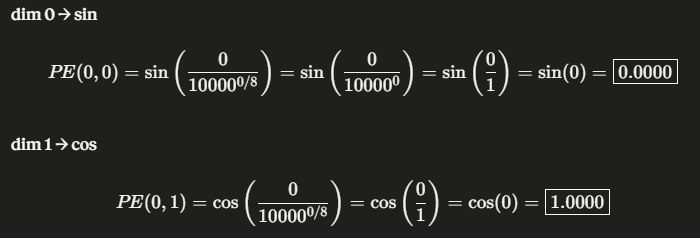

pos=0'da pay hep 0 olduğu için tüm dimler aynı sonucu verir

pos 1 için

dim 0 ve 1 -> i = 0

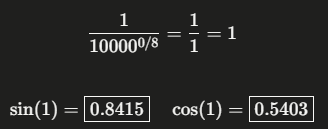

dim 2 ve 3 -> i = 1

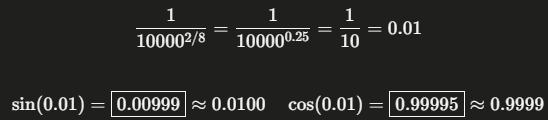

dim 4 ve 5 -> i = 2

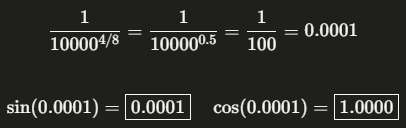

dim 6 ve 7 -> i = 3

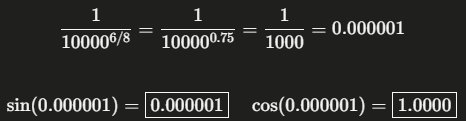

pos=2, d_model=8 için

dim 0 ve 1 -> i = 0

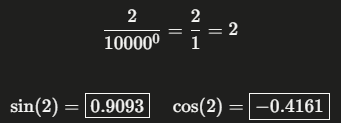

dim 2 ve 3 -> i = 1

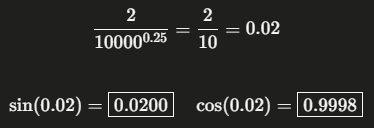

dim 4 ve 5 -> i = 2

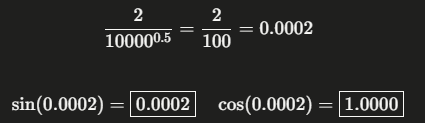

dim 6 ve 7 -> i = 3

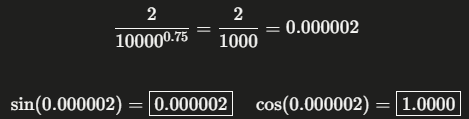